**Task 1 - Identifying target variable**

In [14]:
import pandas as pd

df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [15]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [16]:
df['y'].value_counts()

,count
y,
no,3668
yes,451


As we can see, the column y represents whether or not the client subsrcribebd to a term deposit, which is exactly what the marketing campaign objective is: to predict the subscription.

It's binary, meaning yes/no, which makes it a classification task. Y is uknown since it's the future outcome at a prediction time, hence, y is the correct target. In supervised learning, as we learned the dataset consists of pairs (x,y), where x is the information available at the prediction time and y is the ouctome that occurs after. Y aligns with this structue as well as the campaign objectives.

The two possible variables that could have been picked were 'duration' (it's a numerical value that reflects an outcome of the marketing interaction, meaning longer calls are associated with successfull subscriptions. However, we know this variable only after the call is finished, it's not a business objective and most importantly, the campaign's goal is subscriptiona nd not call length) and 'campaign' (it's a numeric variable that describes the campaign intensity. However, this is not the objective of the campaign, it's an operational variable nad not a success outcome one).

**Task 2 — Data Loading and Exploration**

In [17]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,30,admin.,married,basic.6y,no,yes,yes,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,no
4115,39,admin.,married,high.school,no,yes,no,telephone,jul,fri,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no
4116,27,student,single,high.school,no,no,no,cellular,may,mon,...,2,999,1,failure,-1.8,92.893,-46.2,1.354,5099.1,no
4117,58,admin.,married,high.school,no,no,no,cellular,aug,fri,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


In [18]:
df.shape

(4119, 21)

We observe that the dataset had 4119 observations, which essentially shows us the numbr of rows where each row represents each client interaction with the campaign.

We have 21 number of columns which shows the predictor variables (features) and the target variable. Hence, in total we have 20 predictor variables where one column represents the outcome we are aiming to predict.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

This allows us to determine which columns are numerical and which columns are categorical. The integer and float columns represent the numerical variables while the object columns represent the categorical ones.

It's important to identify what each column is, in order to process the data correctly.

In [20]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


This table shows us the range of all numerical variables, where we can see extreme variables and skewed distributions.

For example: 'duration' has a maximum of 3643 seconds while the median is only 181, indicating strong right skewness and potential extreme values. Similarly, campaign has a median of 2 but a maximum of 35, suggesting skewness.

The variable pdays shows that the 25th, 50th, and 75th percentiles are all 999. This strongly suggests that 999 is a special code rather than a genuine numerical value, meaning this variable requires special consideration before modeling.

In [21]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

numerical_cols, categorical_cols

(Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='object'),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome', 'y'],
       dtype='object'))

We separate the variables into numerical and categorical columns based on their data types. The numerical variables are those stored as int64 or float64, while the categorical variables are stored as object.

This distinction is important because different preprocessing strategies apply to each type. Numerical variables may require scaling or transformation, while categorical variables must be encoded before being used in a Logistic Regression model.

In [22]:
df["y"].value_counts()
df["y"].value_counts(normalize=True)

,proportion
y,
no,0.890507
yes,0.109493


This allows us to see the proprtionality of the dataset. As we can see, 89% corresponds to the class no, while only 11% corresponds to yes. This indicates a clear class imbalance, with the majority class dominating the minority class.

This imbalance is important because it may impact the behavior of the Logistic Regression, since the model may be biased to predicting the majority class unless corrective measures are considered.

In [23]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


We are checking if there are any NaNs in the dataset, and as we can see there are none. However, this does not guarantee that the data is free of missing information. It may contain special categories such as "unknown", therefore, we must also check for that.

In [24]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


job
job
admin.           1012
blue-collar       884
technician        691
services          393
management        324
retired           166
self-employed     159
entrepreneur      148
unemployed        111
housemaid         110
student            82
unknown            39
Name: count, dtype: int64

marital
marital
married     2509
single      1153
divorced     446
unknown       11
Name: count, dtype: int64

education
education
university.degree      1264
high.school             921
basic.9y                574
professional.course     535
basic.4y                429
basic.6y                228
unknown                 167
illiterate                1
Name: count, dtype: int64

default
default
no         3315
unknown     803
yes           1
Name: count, dtype: int64

housing
housing
yes        2175
no         1839
unknown     105
Name: count, dtype: int64

loan
loan
no         3349
yes         665
unknown     105
Name: count, dtype: int64

contact
contact
cellular     2652
telephone    1467

job contains 39 "unknown" entries.

marital contains 11 "unknown" entries.

education contains 167 "unknown" entries.

default contains 803 "unknown" entries.

housing and loan each contain 105 "unknown" entries.

These "uknown" categories indicate missing or unavailable information at data collection. So, we must treat them carefully.

The target distribution confirms a strong class imbalance, which will require careful evaluation and potentially resampling during training.

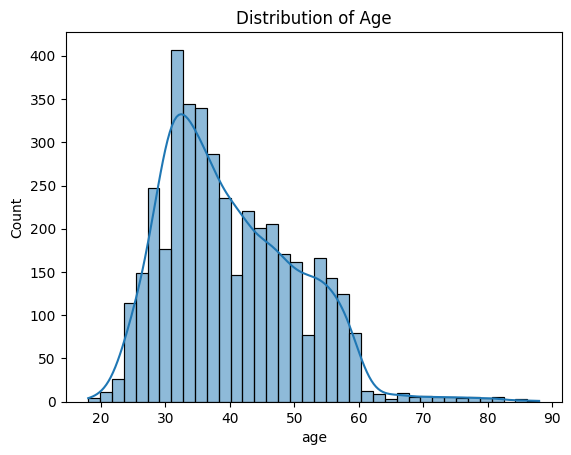

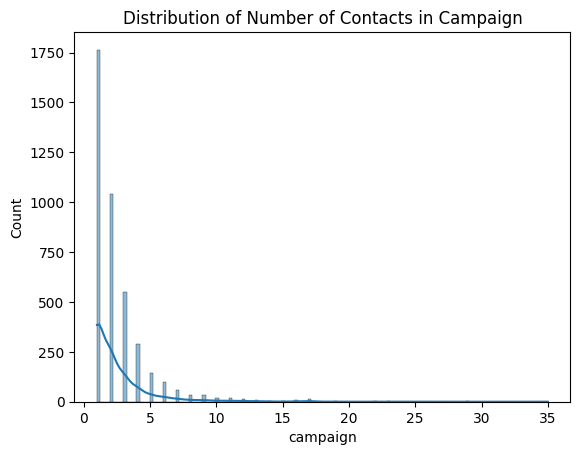

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["age"], kde=True)
plt.title("Distribution of Age")
plt.show()

sns.histplot(df["campaign"], kde=True)
plt.title("Distribution of Number of Contacts in Campaign")
plt.show()

The age distribution falls approximately between 25 and 55 years old, showing less observations at the older ages. We can deduce that age is generally concentrated in th middle of the age range, with a small number of outliers in the older ages.

As we can see the variable 'campaing' is highly right-skewed. The majority of observations are on the lower values. This shows that extreme values are present, and that there is strong skewness.

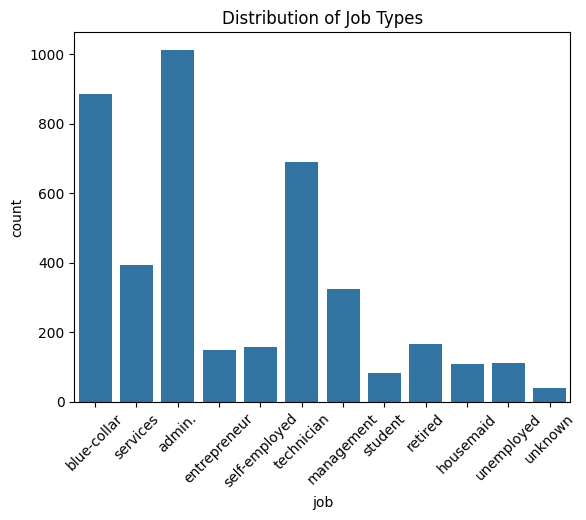

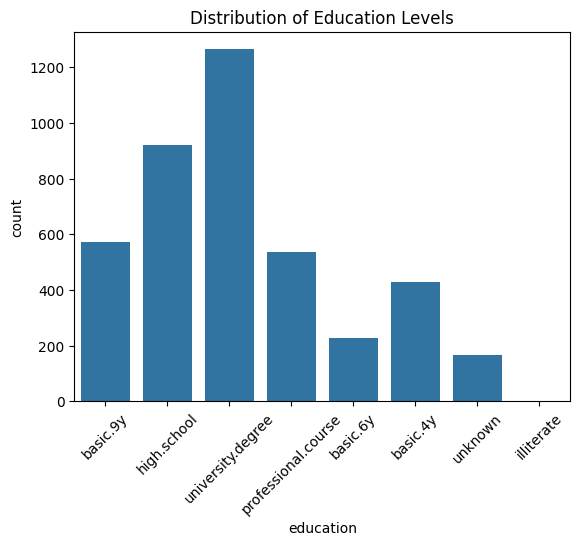

In [26]:
sns.countplot(x="job", data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Job Types")
plt.show()

sns.countplot(x="education", data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Education Levels")
plt.show()

The distribution of job shows that certain categories dominate the dataset, particularly 'admin', 'blue-collar', and 'technician', while categories such as 'student', 'housemaid', and 'unknown' appear much less frequently.

The distribution of 'education' indicates that 'university.degree' and 'high.school' are the most common levels, while categories such as 'illiterate' appear extremely rarely (only one observation).


The variable 'duration' requires special consideration before modeling. It measures the length of the phone call, which is only known after the call has concluded. Since the prediction objective is to determine whether a client will subscribe, using duration would violate the prediction-time constraint and introduce temporal leakage. Therefore, this variable should not be used as a predictor in the model.

**Task 3 — Data Splitting**

In [27]:
X = df.drop("y", axis=1)
y = df["y"]

In [28]:
from sklearn.model_selection import train_test_split

X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,       # 40% temporary
    stratify=y,
    random_state=42
)

We chose 40% because we will split it into validation and test, each will be 20%.

In [29]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,       # half of 40% → 20% total
    stratify=y_temp,
    random_state=42
)

So, we have 60% training, 20% validation and 20% test. The training set is used to learn model parameters, the validation set is used for model evaluation and refining, and the test set is reserved for final performance assessment.

In [30]:
print("Train proportion:")
print(y_train_full.value_counts(normalize=True))

print("\nValidation proportion:")
print(y_val.value_counts(normalize=True))

print("\nTest proportion:")
print(y_test.value_counts(normalize=True))

Train proportion:
y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64

Validation proportion:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

Test proportion:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


Stratified splitting is applied with respect to the target variable to preserve the original class distribution across all subsets. Since the dataset is imbalanced (approximately 89% “no” and 11% “yes”), random splitting without stratification could distort class proportions, leading to unreliable model evaluation.

The split is performed before any preprocessing steps. If operations such as imputation, scaling, encoding, or resampling were applied before splitting, information from the validation or test sets could influence the training process, resulting in data leakage and overly optimistic performance estimates.

**Task 4 — Managing Missing Values**

In [31]:
X_train_full

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
1802,32,technician,married,basic.9y,no,no,no,cellular,jul,fri,271,5,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1
1114,29,blue-collar,single,basic.9y,no,no,no,cellular,may,wed,68,1,999,0,nonexistent,-1.8,92.893,-46.2,1.281,5099.1
2902,22,admin.,single,university.degree,no,yes,no,cellular,sep,mon,194,2,999,3,failure,-1.1,94.199,-37.5,0.882,4963.6
2547,34,services,unknown,high.school,no,yes,yes,cellular,may,tue,369,2,999,1,failure,-1.8,92.893,-46.2,1.344,5099.1
1659,55,blue-collar,divorced,basic.4y,unknown,no,no,cellular,may,wed,130,1,999,1,failure,-1.8,92.893,-46.2,1.281,5099.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,43,blue-collar,married,basic.4y,no,no,yes,cellular,may,wed,69,1,999,1,failure,-1.8,92.893,-46.2,1.281,5099.1
1487,53,services,married,high.school,unknown,yes,no,telephone,jun,thu,75,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1
2895,30,blue-collar,single,basic.9y,unknown,yes,no,cellular,nov,thu,71,2,999,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8
3566,28,self-employed,single,basic.9y,no,no,no,telephone,may,tue,125,3,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0


In [32]:
X_train_full.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


There are no NaNs in the dataset. All variables contain non-null entries. Therefore, no standard imputation is required for explicit missing values.

In [33]:
categorical_cols = X_train_full.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(col)
    print(X_train_full[col].value_counts())
    print()

job
job
admin.           618
blue-collar      505
technician       427
services         249
management       193
retired           97
self-employed     94
entrepreneur      92
housemaid         73
unemployed        57
student           46
unknown           20
Name: count, dtype: int64

marital
marital
married     1490
single       687
divorced     287
unknown        7
Name: count, dtype: int64

education
education
university.degree      759
high.school            581
basic.9y               325
professional.course    323
basic.4y               248
basic.6y               130
unknown                104
illiterate               1
Name: count, dtype: int64

default
default
no         1978
unknown     492
yes           1
Name: count, dtype: int64

housing
housing
yes        1326
no         1090
unknown      55
Name: count, dtype: int64

loan
loan
no         2002
yes         414
unknown      55
Name: count, dtype: int64

contact
contact
cellular     1567
telephone     904
Name: count, dtype: 

Several categorical variables contain the category "unknown", which represents implicit missing information rather than a valid observed category. In particular, default contains a large number of "unknown" entries, suggesting substantial missingness in this variable.

In [34]:
X_train_full["pdays"].describe()

,pdays
count,2471.000000
mean,957.598543
std,198.554323
min,0.000000
25%,999.000000
50%,999.000000
75%,999.000000
max,999.000000


The variable 'pdays' contains the value 999 which can be seen for the majority of observations. This suggests that 999 is not a measurement but a sentinel value, indicating that the client hasn't been contacted before. Hence, we can assume that this represents implicit missingness rather than a true number/quantity.

In [35]:
for col in ["job", "marital", "education", "default", "housing", "loan"]:
    print(col, (X_train_full[col] == "unknown").mean())

job 0.008093889113719142
marital 0.0028328611898017
education 0.04208822339133954
default 0.1991096721974909
housing 0.02225819506272764
loan 0.02225819506272764


We have to quantify the missingness in each variable. In particular, the variable 'default' contains the largest proprotion of "unknown" entires which is around 19%, which indicates solid missingness. On the other hand, other variables displayed in the table also contain smaller proportions of "uknown" values.

In [36]:
(X_train_full["pdays"] == 999).mean()

np.float64(0.9583164710643464)

We have established that the dataset doesn't have NaNs. However, we have seen that some categorical variables contain the category "unknown", which represents the implicit missingness.

We will treat the category of "unknown" as a separate one, rather than removing it. This is doen because the missingness itself might carry some information that it relavant to the analysis.

We have also seen that the variable 'pdays', has 999 as a sentinel value and we will treat it as an indicator of "not previously contacted". We will not treat this as a numerical value but create a binary indicator varibale instead, which will capture whether the client has been previously contacted and adjust the numerical representation accordingly.

Deciding to treat the variable 'pdays' as a sentinel value is a data cleaning decision, since it corrects a numerical encoding which doesn't represent a true measurement. On the other hand, keeping the "unkown" as a separate category is a modeling decision, since in this case, missingness itself could carry relavant information.

All transformations that require learning parameters will be fitted using only the training set, followinf the pipeline discipline. This will prevent information leakage from validation or test sets.